In [1]:
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import visualization.visualization as vis
from nemi import NEMI, SingleNemi

import torch
import numpy as np

import colorsys
from einops import rearrange
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

import itertools

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="2_01",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

23 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl','SIarea','XC','YC']


In [3]:
#data_channels = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl']

data_channels_small = ['Eta','Salt','Theta','relative_vorticity','gradb2','oceQnet','wind_stress_curl']
#data_channels_engineered = ['gradb2','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','oceQnet','ekman_pumping','wind_stress_curl']
dataset = cutouts_dataset.CutoutDataset.from_source(data_channels=data_channels_small, source=source, subset=False,
                                                    subsample_per_chunk=64, num_sample_chunks=1, n_workers=4)

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37449 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:44053' processes=4 threads=40, memory=200.00 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/37449/status
dropped 12 ice, 10 NaN; kept 29492 / 29511
features ['Eta', 'Salt', 'Theta', 'relative_vorticity', 'gradb2', 'oceQnet', 'wind_stress_curl'] | coords ['XC', 'YC']


In [20]:
import math

patch_size = 8
patches = dataset.get_patches(patch_size=patch_size)   # (N_patches, C_feat*p*p), coords excluded

print(patches.shape)
print(math.log(patches.shape[0]) + 15)

(1887488, 448)
29.450757402469215


In [7]:
EMBEDDING_DIMENSIONS = 2
ENSEMBLE_MEMEBERS = 1

In [17]:
## Run NEMI on the patches (GPU: cuML UMAP + clustering)
# nemi = NEMI(params={
#     "device": "gpu",
#     "embedding_dict":  {"n_components": 3, "n_neighbors": 57, "min_dist": 0.0},
# })

nemi = NEMI(params={
    "device": "gpu",
    "method": "tsne",
    "embedding_dict":  {"n_components": 2, "perplexity": 50},
})


# nemi = NEMI(params={
#     "device": "gpu",
#     "embedding_dict":  {"n_components": EMBEDDING_DIMENSIONS, "n_neighbors": 15, "min_dist": 0.0},
#     "clustering_dict": {"method": "agglomerative", "n_clusters": 20, "linkage": "single", "n_neighbors": 30},
# })


# EMBEDDING ONLY 
nemi.run(patches, n=ENSEMBLE_MEMEBERS, output="nemi_out.npz", assess_overlap=True, mode="embed", embeddings="nc3_nn57_dist0_umap.npz")

  0%|          | 0/1 [00:00<?, ?it/s]

[2026-08-11 02:30:01.425] [CUML] [info] Unused keyword parameter: perplexity during cuML estimator initialization
[2026-08-11 02:30:02.057] [CUML] [info] Building knn graph using nn descent


100%|██████████| 1/1 [00:23<00:00, 23.65s/it]

[2026-08-11 02:30:23.816] [CUML] [warning] Spectral initialization failed, using random initialization instead.


In [19]:
vis.vis_dim_redux(nemi.embedding, dims=EMBEDDING_DIMENSIONS, alpha=0.1)

AttributeError: 'NEMI' object has no attribute 'embedding'

In [12]:
# nemi = NEMI(params={
#     "device": "cpu",
#     "clustering_dict": dict(method="agglomerative", linkage="ward",
#                          n_clusters=300, n_neighbors=40),
# })

# nemi = NEMI(params={
#     "device": "gpu",
#     "embedding_dict":  {"n_components": 3, "n_neighbors": 57, "min_dist": 0.0},
#     "clustering_dict": {"method": "kmeans", "n_clusters": 400},
# })

nemi = NEMI(params={
    "device": "gpu",
    "clustering_dict": {"method": "dbscan", "eps": 0.08, "min_samples":50},
})


nemi.run(output="nemi_out.npz", assess_overlap=True, mode="cluster", embeddings="nc3_nn57_dist0_umap.npz")

dataset.save_cluster_labels("nemi_clusters.parquet", nemi.clusters, patch_size=patch_size)

Loaded 1 embedding(s) from nc3_nn57_dist0_umap.npz
Embedding | device=gpu | {'n_components': 2, 'perplexity': 40}


  0%|          | 0/1 [00:00<?, ?it/s]

Clustering | device=gpu | {'method': 'dbscan', 'eps': 0.08, 'min_samples': 50}
[2026-08-11 01:53:12.132] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 3592 -> 1137. Using the larger integer type might result in better performance


100%|██████████| 1/1 [01:05<00:00, 65.37s/it]

Clusters found: 92


In [13]:
d = np.load("nemi_out.npz")
print(d.files) 

try :
    member_clusters = d["member_clusters"]  # (n, N)  per-member labels  <- entropy input
    embeddings      = d["embeddings"]       # (n, N, d) per-member UMAP embeddings
    clusters        = d["clusters"]         # (N,)   consensus labels (assess_overlap ran)
    embedding       = d["embedding"]        # (N, d) consensus/base embedding
    entropy         = d["entropy"]
    unassigned      = d["unassigned_frac"]
    
    print(embeddings.shape)
    print(member_clusters.shape)
    print(clusters.shape)
    print(embedding.shape)
    print(entropy.shape)
    print(unassigned.shape)

except :
    embeddings      = d["embedding"]       # (n, N, d) per-member UMAP embeddings
    clusters        = d["clusters"]  

['embedding', 'clusters']


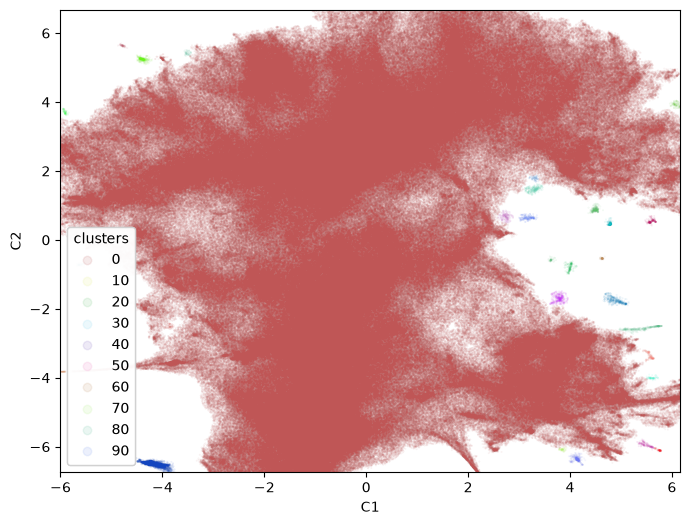

In [14]:
#labeled by consensus cluster
if ENSEMBLE_MEMEBERS > 1:
    vis.vis_dim_redux_list(embeddings, labels=clusters, dims=EMBEDDING_DIMENSIONS, titles=[f"member {i}" for i in range(len(embeddings))], alpha=0.4)
else:
    vis.vis_dim_redux(embeddings, labels=clusters, label_title="clusters", dims=EMBEDDING_DIMENSIONS, alpha=0.1)

In [35]:
# vis.vis_dim_redux(embeddings[1], labels=entropy, dims=2, alpha=0.5, categorical=False, cmap="viridis")

vis.vis_dim_redux_list(d["embeddings"], labels=entropy, dims=EMBEDDING_DIMENSIONS, alpha=0.2,titles=[f"member {i}" for i in range(len(d["embeddings"]))], categorical=False, cmap="viridis")

KeyError: 'embeddings is not a file in the archive'

In [ ]:
vis.vis_dim_redux_list(d["embeddings"], labels=unassigned, dims=EMBEDDING_DIMENSIONS, alpha = 0.5,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))], categorical=False, cmap="viridis")

In [ ]:
# colored by embedding's clustering
vis.vis_dim_redux_list(d["embeddings"], labels=d["member_clusters"], dims=EMBEDDING_DIMENSIONS, alpha=0.5,
                   titles=[f"member {i}" for i in range(len(d["embeddings"]))])

In [15]:
np.unique(clusters)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

In [11]:
#  

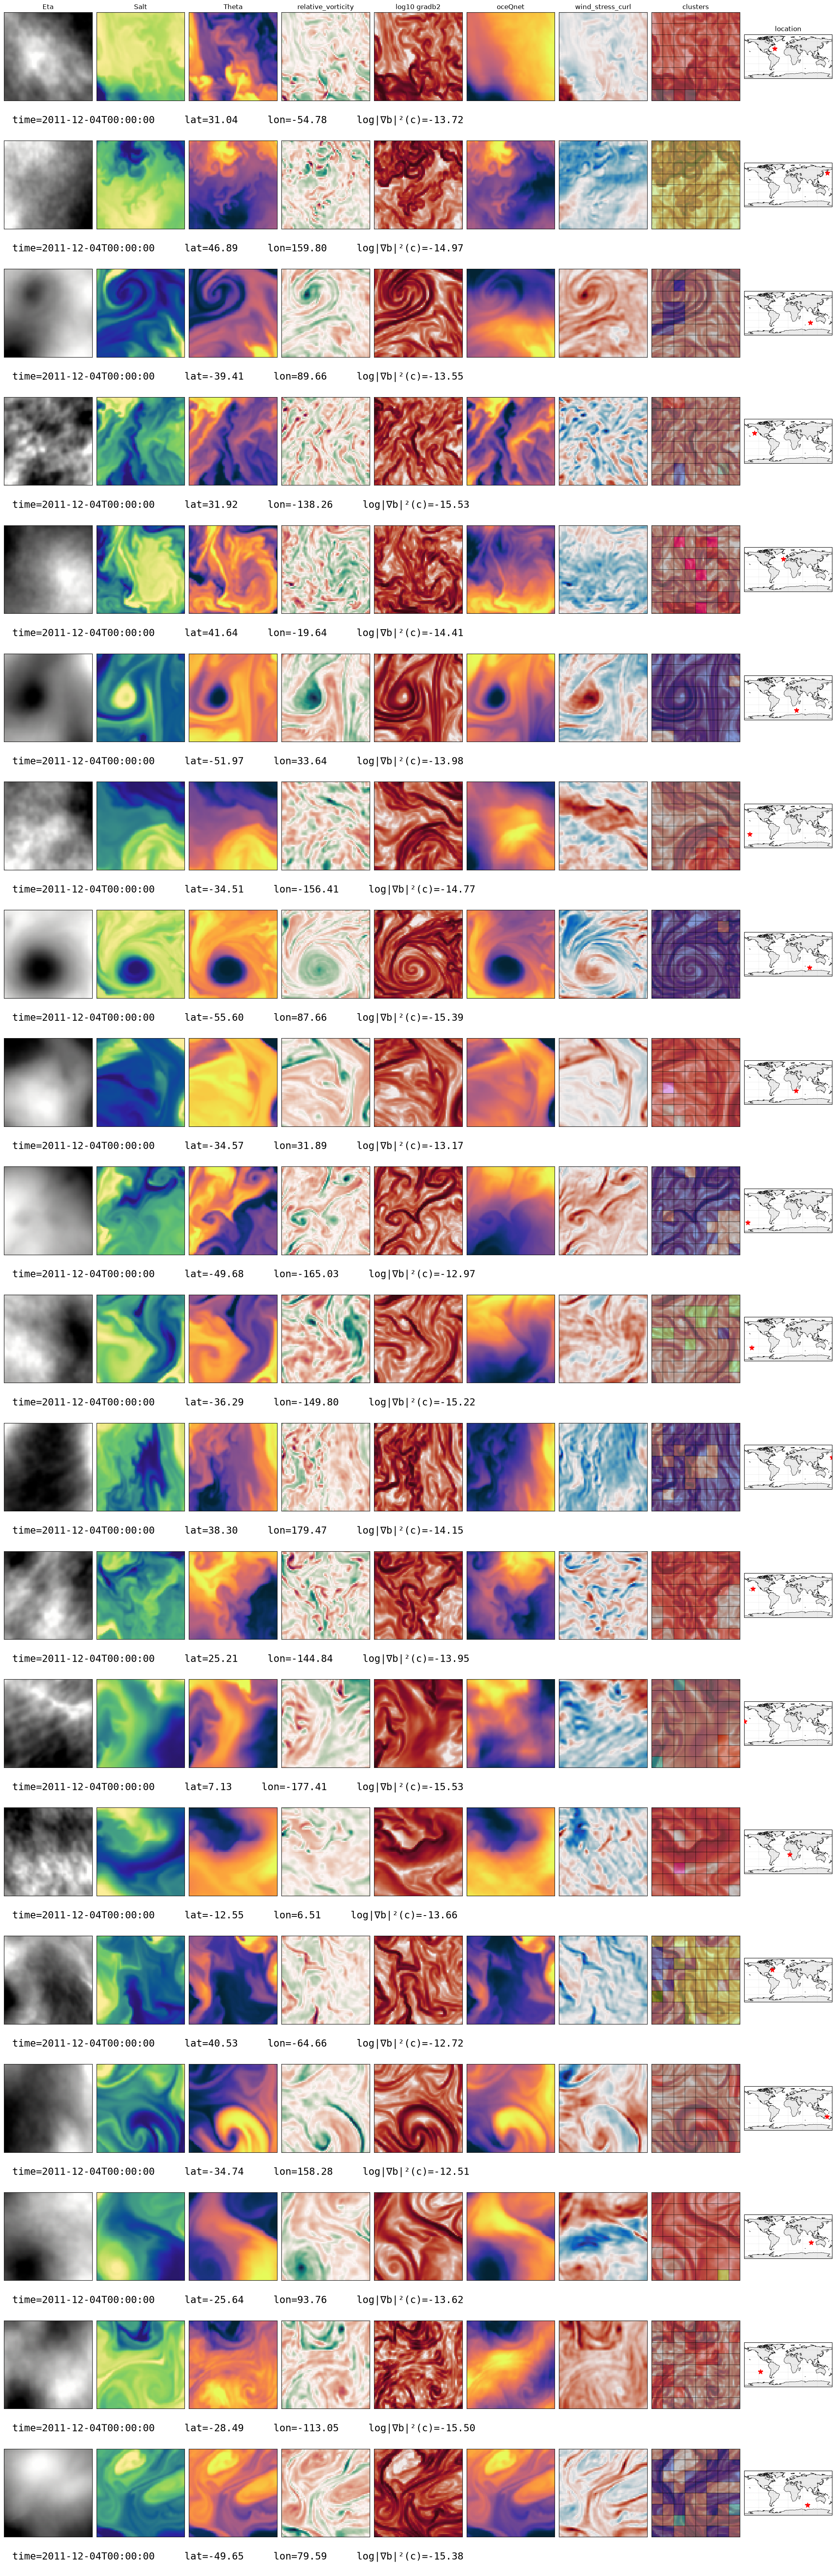

In [37]:
vis.make_image_from_patches(dataset, clusters, patch_size=8, number_rows=20, overlay_alpha=0.5, show_map=True)

# Cluster composition

Where the ~450 DBSCAN clusters sit in the data, what they hold, and where they
are found.  `-1` (noise) is kept throughout as a cluster of its own.

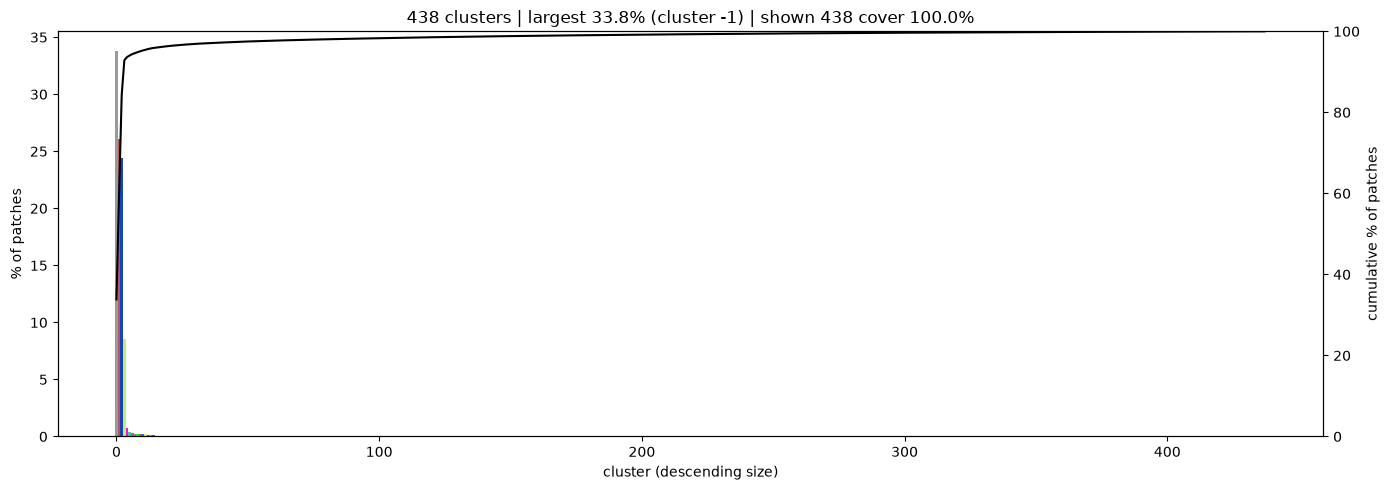

In [38]:
ids, pct = vis.plot_cluster_size_distribution(clusters)
#print(f"noise (-1) holds {pct[ids == -1][0]:.1f}% | top 20 clusters cover {pct[:20].sum():.1f}%")

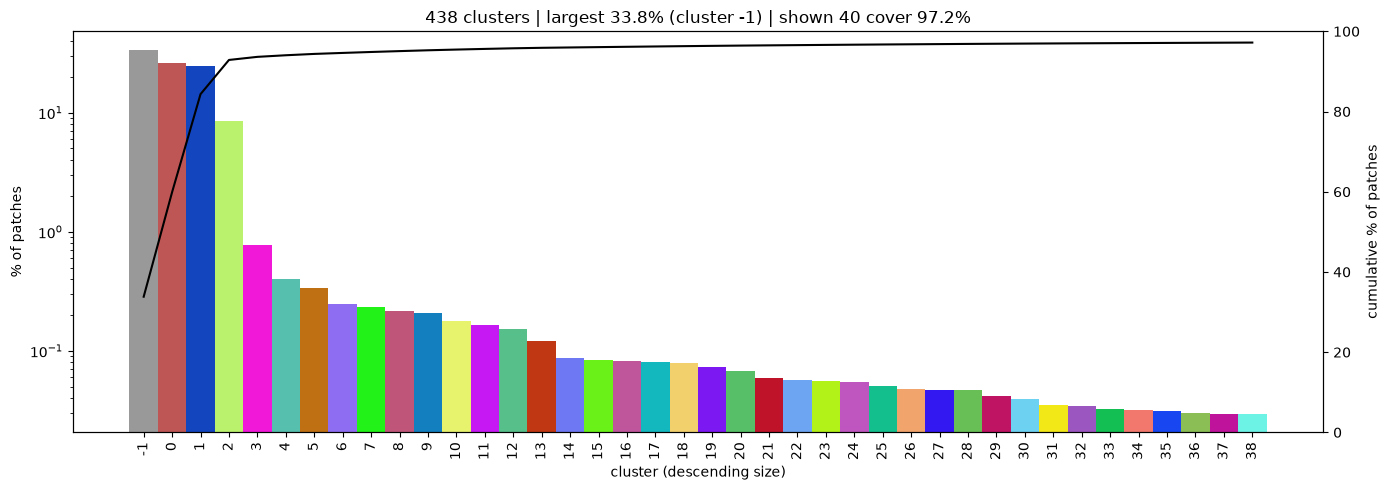

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
        33, 34, 35, 36, 37, 38]),
 array([3.38268641e+01, 2.60823910e+01, 2.44330560e+01, 8.52254425e+00,
        7.71819476e-01, 3.98254188e-01, 3.34465703e-01, 2.46200241e-01,
        2.35233284e-01, 2.17166944e-01, 2.06464889e-01, 1.79603791e-01,
        1.63550709e-01, 1.53431439e-01, 1.20636529e-01, 8.68349891e-02,
        8.45568290e-02, 8.22256883e-02, 8.00534891e-02, 7.94707039e-02,
        7.29541062e-02, 6.70732741e-02, 5.87553404e-02, 5.69010240e-02,
        5.54705513e-02, 5.52586295e-02, 5.10201919e-02, 4.74175200e-02,
        4.72585786e-02, 4.66757934e-02, 4.16426489e-02, 3.96293910e-02,
        3.53909535e-02, 3.44902855e-02, 3.26889495e-02, 3.18942425e-02,
        3.09935745e-02, 3.03578089e-02, 2.94041605e-02, 2.94041605e-02]))

In [42]:
# long tail: the same distribution on a log axis, largest 40 only
vis.plot_cluster_size_distribution(clusters, top_n=40, log=True)

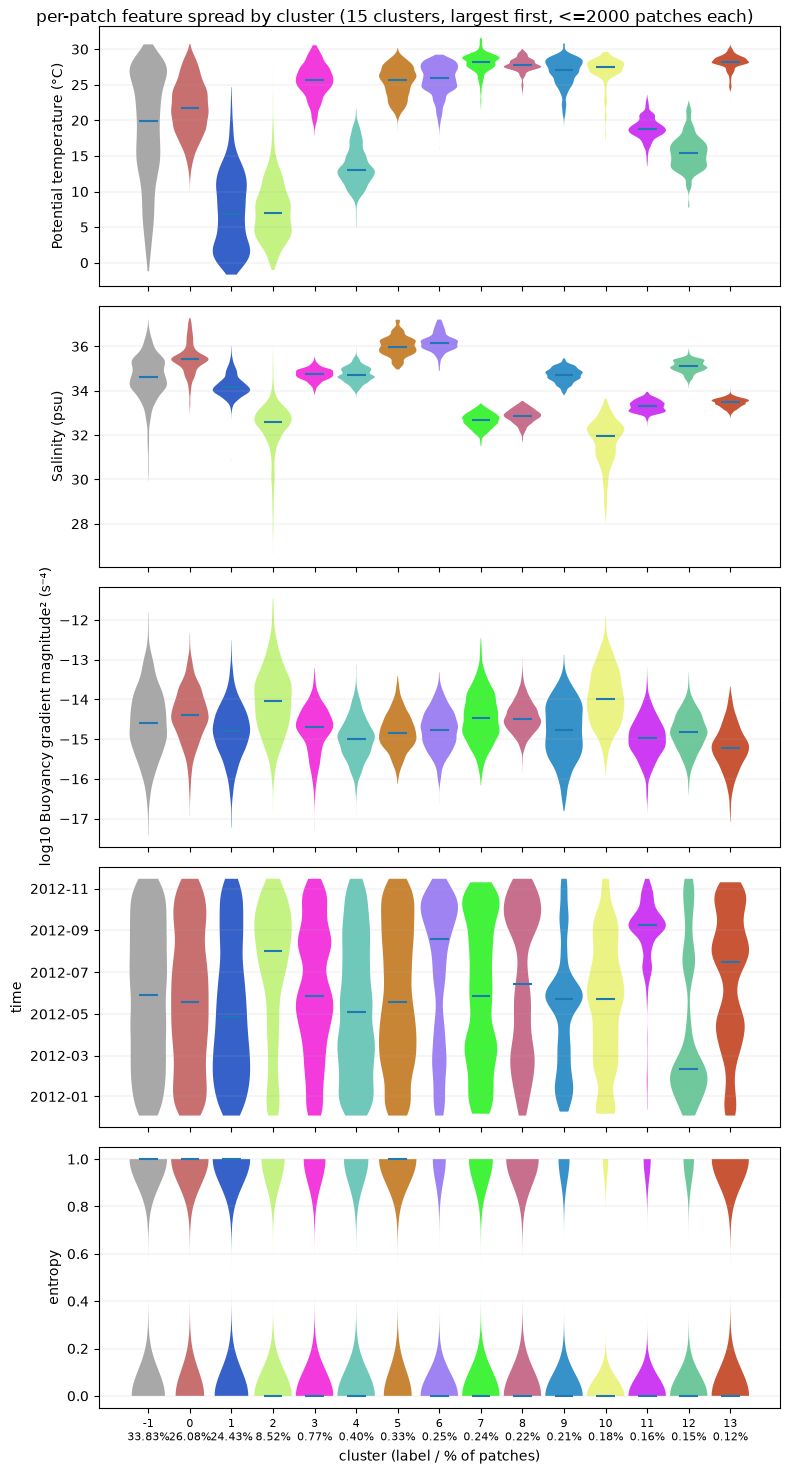

In [41]:
# feature spread within the largest clusters
vis.plot_cluster_feature_spread(dataset, clusters, features=["Theta", "Salt", "gradb2"],
                                patch_size=patch_size, top_n=15,
                                entropy=entropy, show_time=True)

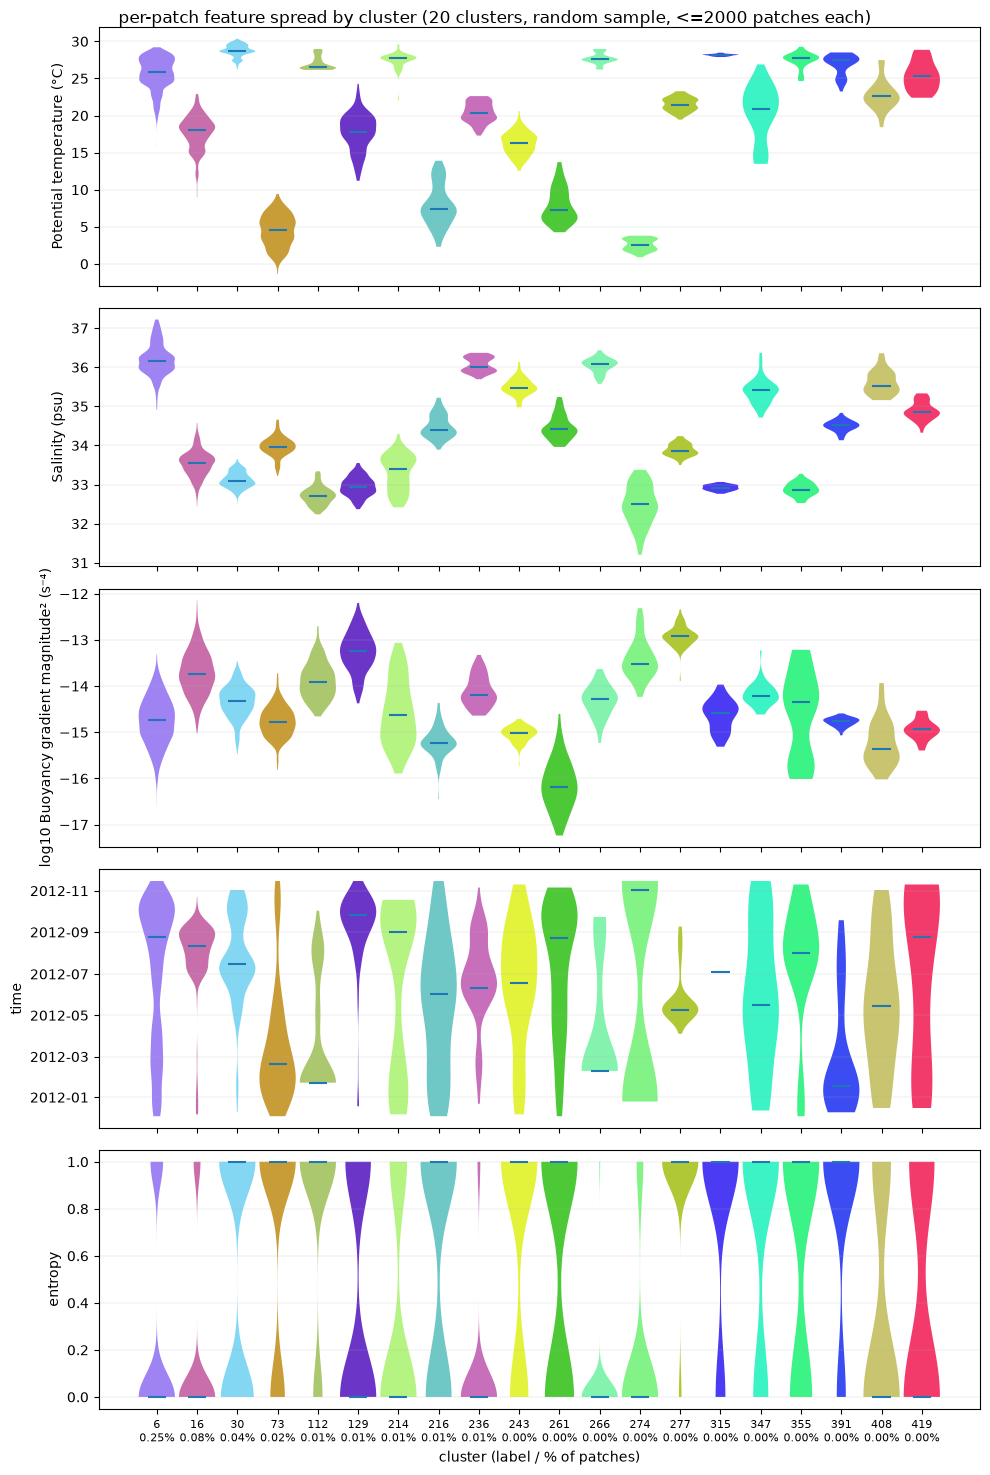

In [43]:
# same, for a random sample of clusters of any size
vis.plot_cluster_feature_spread(dataset, clusters, features=["Theta", "Salt", "gradb2"],
                                patch_size=patch_size, n_clusters=20, seed=0,
                                entropy=entropy, show_time=True)

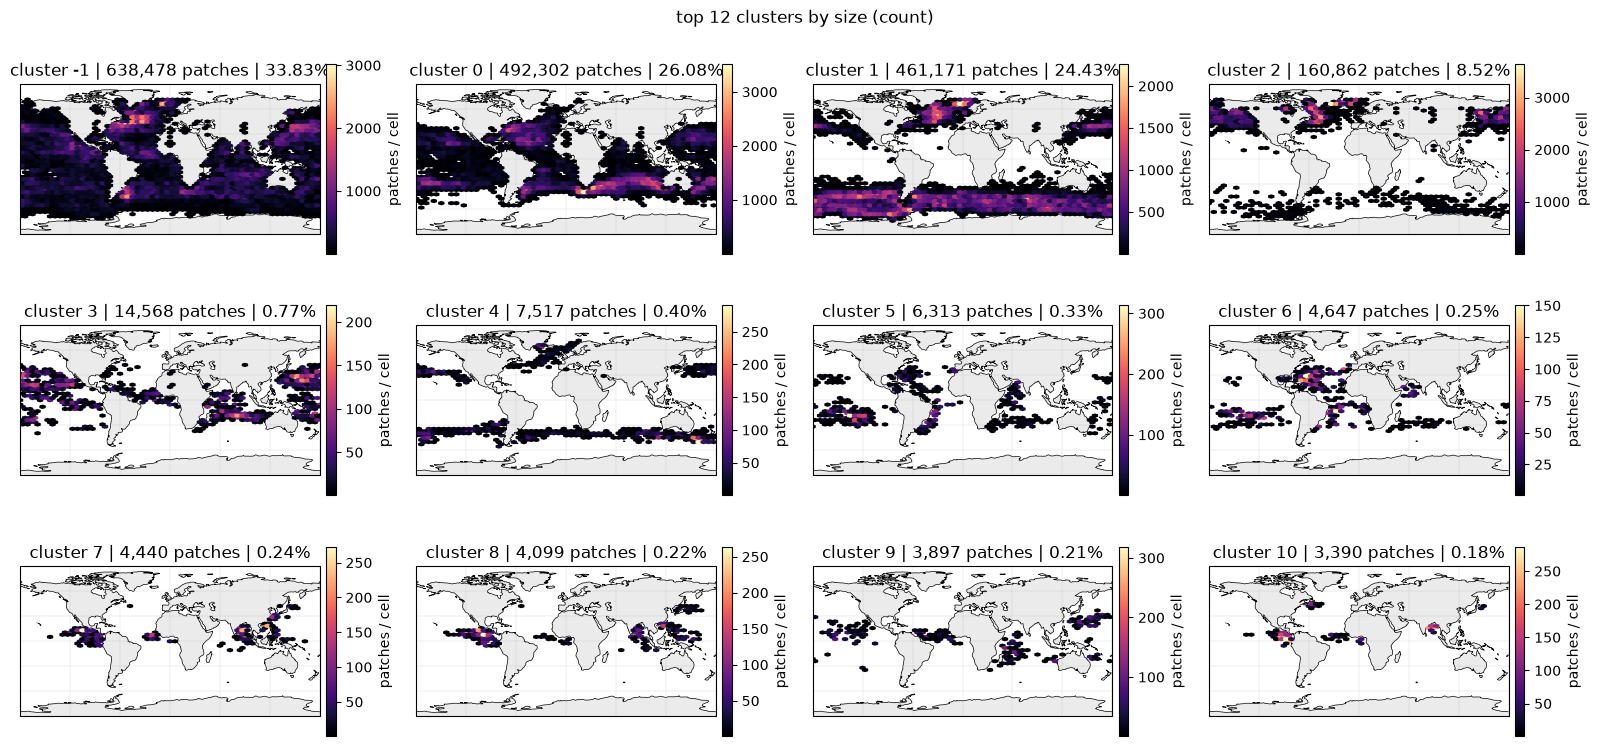

In [44]:
vis.plot_top_cluster_maps(dataset, clusters, patch_size=patch_size, top_n=12, n_cols=4)

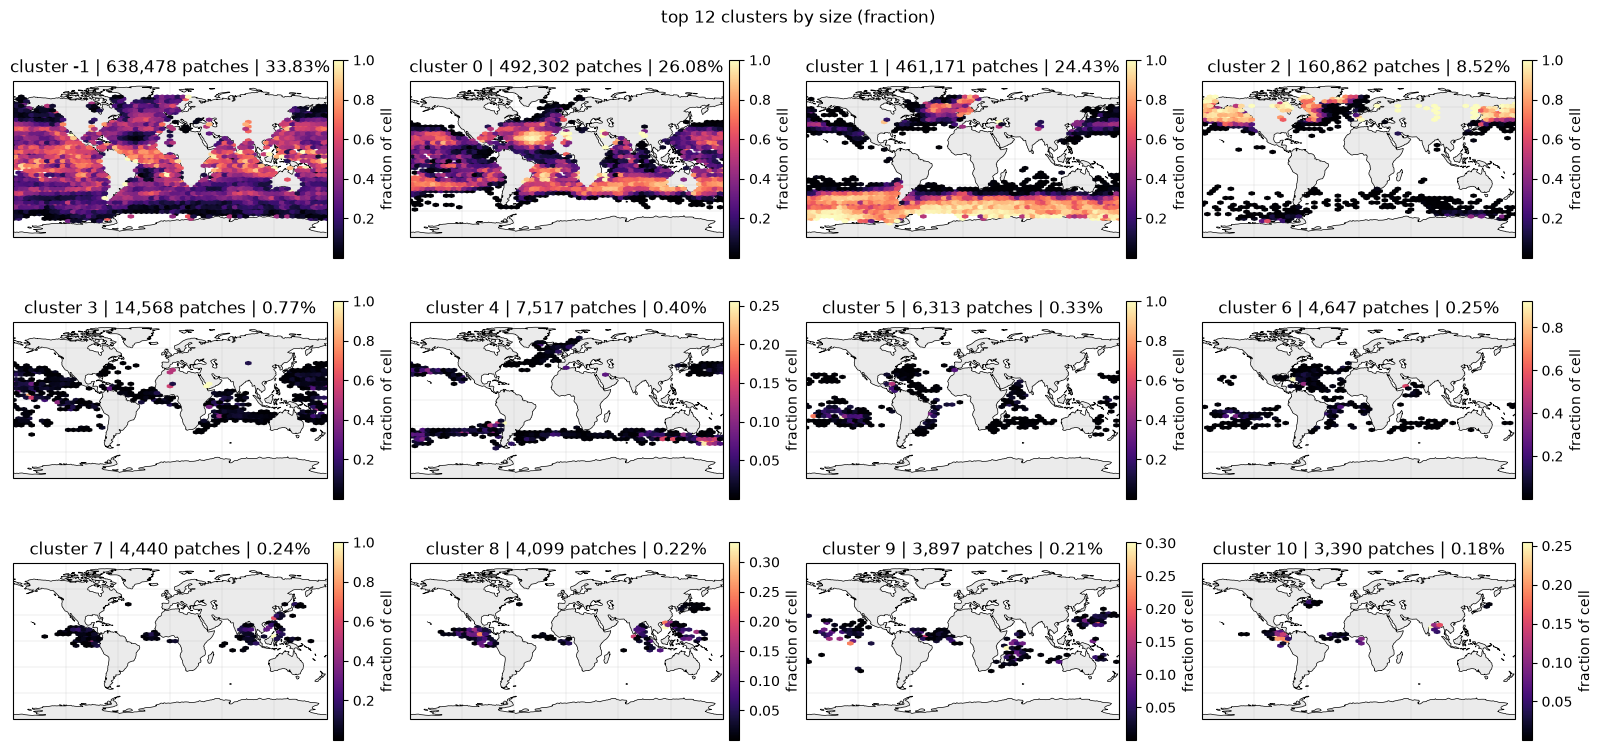

In [45]:
# prevalence instead of raw counts, which divides out the uneven sampling density
vis.plot_top_cluster_maps(dataset, clusters, patch_size=patch_size, top_n=12, n_cols=4,
                          normalize="fraction")

cluster 0: 15,500 patches across 1,598 cutouts | richest holds 54 of 64


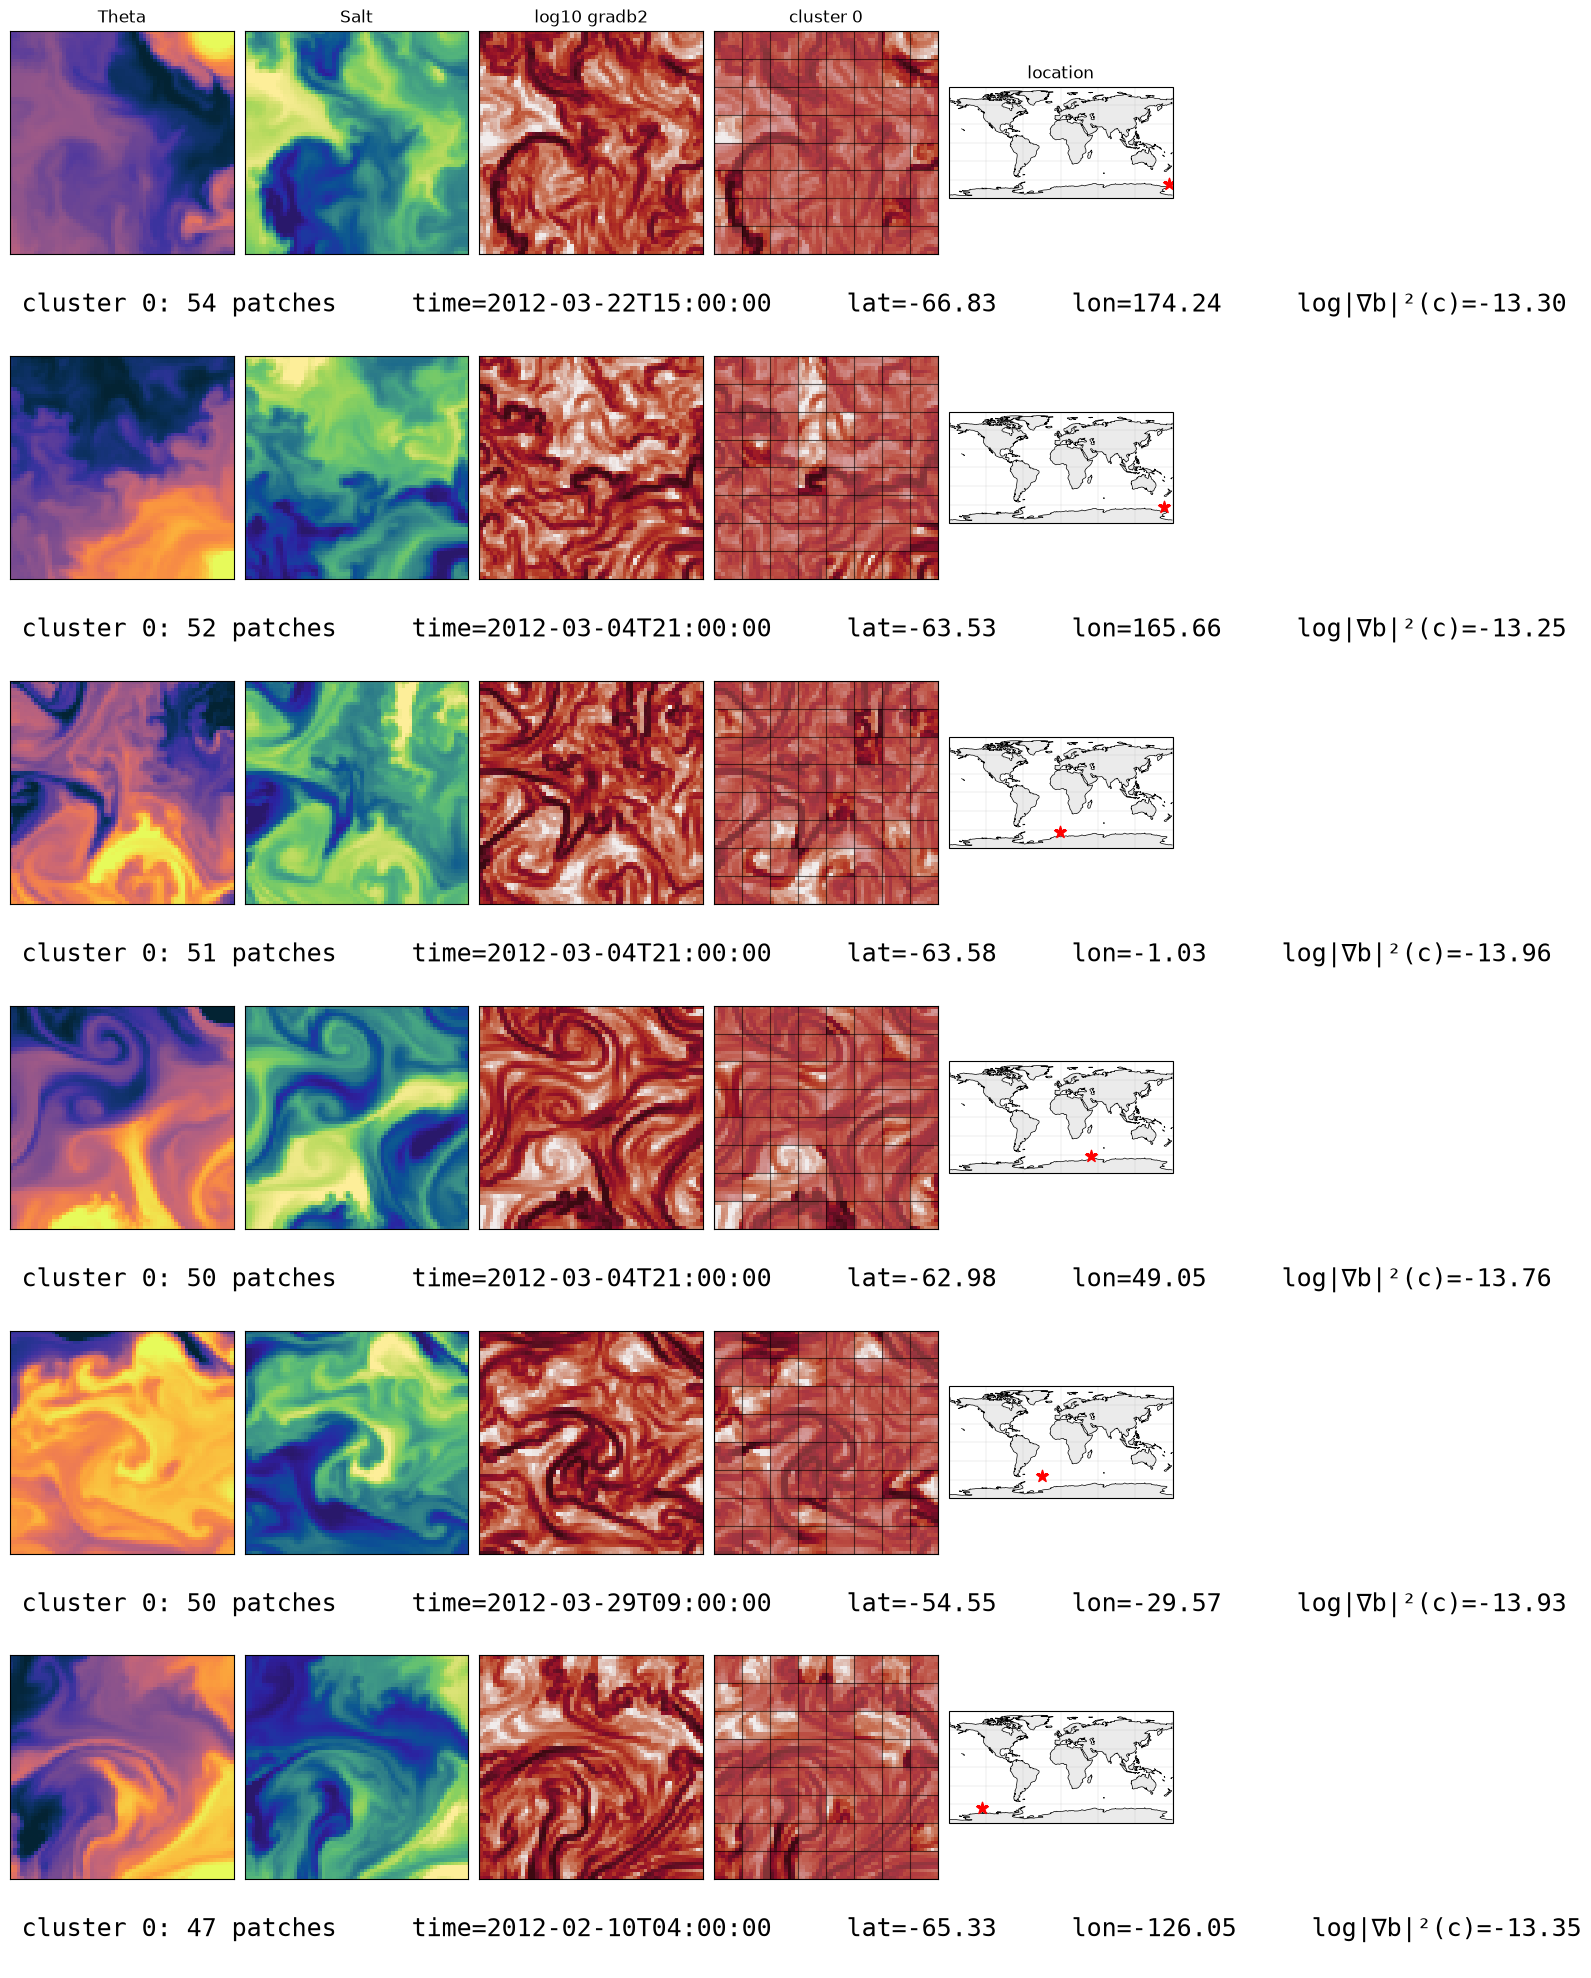

In [19]:
# cutouts holding a given cluster, richest first; `cluster` is the actual label
# shown by the maps above, not a size rank
top_cluster = int(ids[ids >= 0][0])
vis.plot_cluster_cutouts(dataset, clusters, top_cluster,
                         features=["Theta", "Salt", "gradb2"],
                         patch_size=patch_size, number_rows=6)

cluster 7: 9,442 patches across 431 cutouts | richest holds 64 of 64


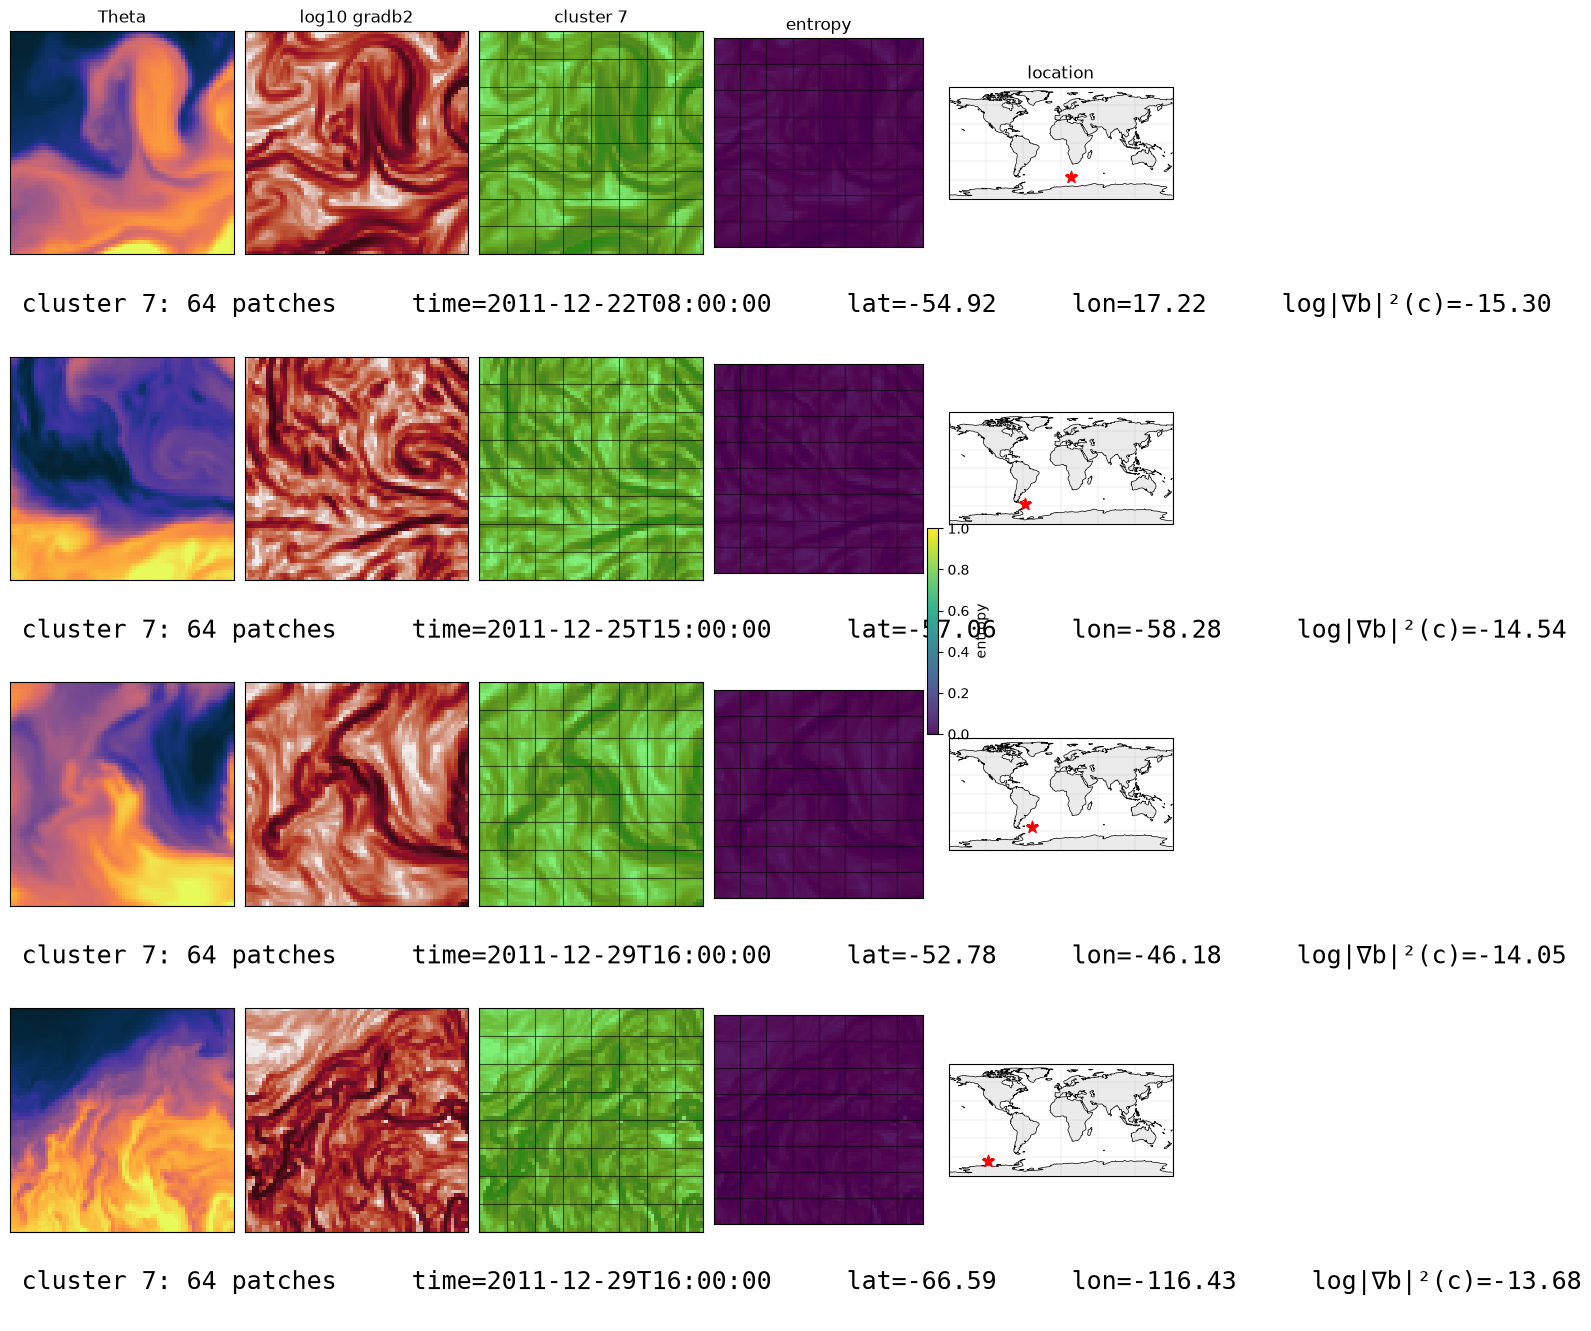

In [20]:
# any label works, and entropy adds its own column
vis.plot_cluster_cutouts(dataset, clusters, 7,
                         features=["Theta", "gradb2"], patch_size=patch_size,
                         number_rows=4, start=6, entropy=entropy)